<a href="https://colab.research.google.com/github/UkigawaSaeko/MATH5380-project/blob/main/project1_multi_asset_bl_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 Notebook: Long-Only Multi-Asset Portfolio with Black-Litterman Tilts

这个 notebook 使用教授给的 Excel 数据，完成：
- 数据清洗与对齐
- 市场权重与两组有统一故事线的观点（美国成长相对非美成长；投资级美综合债相对全球高收益）
- Black-Litterman 预期收益
- 年度再平衡（long-only + 权重和为1 + 相对市场单资产偏离±5%）
- 月度回测与可视化
- 关键统计量输出

In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
plt.style.use("seaborn-v0_8")

In [5]:
# 1) 读取 Excel
excel_path = Path("/content/Data for final project 1.xlsx")

print("Using Excel:", excel_path)

returns_raw = pd.read_excel(excel_path, sheet_name="Index returns in USD")
mv_raw = pd.read_excel(excel_path, sheet_name="Market values in USD")

# 列名映射：把 market values 的名称对齐到 returns 命名
name_map = {
    "Bloomberg Barclays Global Inflation-Linked": "Bloomberg Barclays Global Inflation-Linked USD",
    "Bloomberg Barclays Municipal Bond": "Bloomberg Barclays US Municipal Bond",
    "Bloomberg Barclays Global High Yield": "Bloomberg Barclays Global High Yield USD",
}
mv_raw = mv_raw.rename(columns=name_map)

# 日期处理
def parse_yyyymmdd(x):
    return pd.to_datetime(str(int(x)), format="%Y%m%d")

returns_raw["Date"] = returns_raw["Date"].apply(parse_yyyymmdd)
mv_raw["Date"] = mv_raw["Date"].apply(parse_yyyymmdd)

returns_raw = returns_raw.sort_values("Date").reset_index(drop=True)
mv_raw = mv_raw.sort_values("Date").reset_index(drop=True)

print("Returns shape:", returns_raw.shape)
print("Market values shape:", mv_raw.shape)


Using Excel: /content/Data for final project 1.xlsx
Returns shape: (300, 20)
Market values shape: (223, 18)


In [6]:
# 2) 资产池：使用两张表共有资产（并且有市场权重）
common_assets = [c for c in returns_raw.columns if c in mv_raw.columns and c != "Date"]
print("Common assets:", len(common_assets))
print(common_assets)

returns = returns_raw[["Date"] + common_assets].copy()
mv = mv_raw[["Date"] + common_assets].copy()

# 后续按日期索引
returns = returns.set_index("Date")
mv = mv.set_index("Date")

# 月度收益必须是小数（文件已是小数）
assert returns.abs().max().max() < 1.0, "Returns seems not in decimal format."

Common assets: 17
['Russell 1000 Value', 'Russell 1000 Growth', 'Russell 2000 Value', 'Russell 2000 Growth', 'MSCI World Ex USA Value NR USD', 'MSCI World Ex USA Growth NR USD', 'MSCI World Ex USA Small Value NR USD', 'MSCI World Ex USA Small Growth NR USD', 'MSCI EM Value NR USD', 'MSCI EM Growth NR USD', 'MSCI EM Small Value NR USD', 'MSCI EM Small Growth NR USD', 'Bloomberg Barclays US Aggregate', 'Bloomberg Barclays Global Aggregate x USD', 'Bloomberg Barclays Global Inflation-Linked USD', 'Bloomberg Barclays US Municipal Bond', 'Bloomberg Barclays Global High Yield USD']


In [7]:
# 3) Black-Litterman + 优化函数

def nearest_psd(cov: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """简单修正，避免数值不稳定导致非正定。"""
    cov = (cov + cov.T) / 2
    vals, vecs = np.linalg.eigh(cov)
    vals = np.clip(vals, eps, None)
    return vecs @ np.diag(vals) @ vecs.T


def bl_posterior(pi, sigma, P, Q, tau=0.05, omega_scale=4.0):
    """
    pi: market implied returns (N,)
    sigma: annualized covariance (N,N)
    P: view matrix (K,N)
    Q: view returns (K,)
    omega_scale: >1 表示更弱置信度
    """
    ts = tau * sigma
    mid = P @ ts @ P.T
    omega = np.diag(np.diag(mid)) * omega_scale

    inv_ts = np.linalg.inv(ts)
    inv_omega = np.linalg.inv(omega)

    m = np.linalg.inv(inv_ts + P.T @ inv_omega @ P)
    mu_bl = m @ (inv_ts @ pi + P.T @ inv_omega @ Q)
    return mu_bl, omega


def optimize_long_only(mu, sigma, delta, w_mkt, max_dev=0.05):
    n = len(mu)

    def obj(w):
        return 0.5 * delta * (w @ sigma @ w) - (mu @ w)

    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)

    # 每个资产相对市场权重偏离限制 ±5%
    lb = np.maximum(0.0, w_mkt - max_dev)
    ub = np.minimum(1.0, w_mkt + max_dev)
    bounds = list(zip(lb, ub))

    # 如果边界导致不可行，退化为普通 long-only
    if lb.sum() > 1.0 or ub.sum() < 1.0:
        bounds = [(0.0, 1.0)] * n

    w0 = w_mkt.copy()

    res = minimize(obj, w0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        # 兜底：去掉相对偏离约束，再求一次
        res = minimize(obj, w0, method="SLSQP", bounds=[(0.0, 1.0)] * n, constraints=cons)

    if not res.success:
        raise RuntimeError(f"Optimization failed: {res.message}")

    w = np.clip(res.x, 0.0, 1.0)
    w = w / w.sum()
    return w

In [8]:
# 4) 参数与观点（至少两个 tilt）
# ---------------------------------------------------------------------------
# 故事线（可写入报告 “Tilts / Views” 小节）：
#  在 2007 年后多轮流动性冲击与风险重定价环境下，用两条**互补的**相对收益观点，
#  形成统一逻辑：
#   (A) 权益：在**同一“成长”风格**下，美国 large-cap 相对**非美发达**成长的一点点优势
#       （美元市场深度、流动性与信息环境等——表述为**结构性、温和**的跨市场 premium，
#       而非短期动量）。
#   (B) 固收：在**信用/周期贝塔**维度上，偏好**投资级美国综合**相对**全球高收益**的温和 tilt
#       （久期+信用质量与 HY 的周期性的对比）。
#  两条线分别落在股票 / 债券，不重复押同一种 style-only 的 EM vs DM 或成长 vs 价值。
# ---------------------------------------------------------------------------
assets = common_assets
n = len(assets)
idx = {a: i for i, a in enumerate(assets)}

# 风险厌恶系数（全程固定）
delta = 2.5
# BL tau 与观点置信度（通过 omega_scale 控制）
tau = 0.05
omega_scale = 4.0  # 越大，观点越弱

P = np.zeros((2, n))
Q = np.zeros(2)

# View 1: Russell 1000 Growth 相对 MSCI World ex USA Growth（发达市场、同风格跨区域）
if "Russell 1000 Growth" in idx and "MSCI World Ex USA Growth NR USD" in idx:
    P[0, idx["Russell 1000 Growth"]] = 1.0
    P[0, idx["MSCI World Ex USA Growth NR USD"]] = -1.0
    Q[0] = 0.0075  # 年化相对超额 0.75%，幅度温和

# View 2: US Aggregate 相对 Global High Yield（固收、信用/质量维度）
if "Bloomberg Barclays US Aggregate" in idx and "Bloomberg Barclays Global High Yield USD" in idx:
    P[1, idx["Bloomberg Barclays US Aggregate"]] = 1.0
    P[1, idx["Bloomberg Barclays Global High Yield USD"]] = -1.0
    Q[1] = 0.004  # 年化 40bp 量级，避免与股票 spread 同尺度显得过强

print("delta=", delta, "tau=", tau, "omega_scale=", omega_scale)
print("P shape:", P.shape, "Q (annual long-short):", Q)
print("Narrative: (1) US vs ex-US **Growth**  (2) US IG Agg vs **Global HY**")

delta= 2.5 tau= 0.05 omega_scale= 4.0
P shape: (2, 17) Q (annual long-short): [0.0075 0.004 ]
Narrative: (1) US vs ex-US **Growth**  (2) US IG Agg vs **Global HY**


In [9]:
# 5) 年度再平衡 + 回测
# 规则：在每年 y 的最后一个「有市值」观测日 reb_date 处决定组合，用于持有「下一日历年」y+1 的全部月度收益。
#
# 无前视偏差要点（与作业 Note 2 一致）：
# - 协方差与 BL 仅用 reb_date 已实现的月度收益；绝不使用持有年 y+1 的收益。
# - 市值权重用当日 mv.loc[reb_date]（构造当日可得）。
# - 可选：不把 reb_date 当月收益放进协方差窗口（更保守）。默认 False，与常见「月末可得当月收益」假设一致。

EXCLUDE_REBALANCE_MONTH_FROM_COV = False

mv_year_end = mv.groupby(mv.index.year).tail(1).copy()
available_years = sorted(mv_year_end.index.year.unique())

weights_opt = {}
weights_mkt = {}
mu_pi_dict = {}
mu_bl_dict = {}
cov_dict = {}

port_rets = []
bmk_rets = []

for y in available_years:
    # 本循环内每年重算 Sigma, pi, mu_bl, w_opt（不跨 y 复用）
    reb_date = mv_year_end[mv_year_end.index.year == y].index.max()

    hold_mask = returns.index.year == (y + 1)
    if hold_mask.sum() == 0:
        continue

    hold_dates = returns.index[hold_mask]

    if EXCLUDE_REBALANCE_MONTH_FROM_COV:
        hist = returns.loc[returns.index < reb_date].tail(36)
    else:
        hist = returns.loc[returns.index <= reb_date].tail(36)

    if len(hist) < 36:
        continue

    # --- 无前视断言：估计样本与持有期样本不得重叠；持有期严格在 reb_date 之后 ---
    overlap = hist.index.intersection(hold_dates)
    assert overlap.empty, f"year y={y}: hist 与持有期日期重叠 {list(overlap[:3])}..."
    assert hold_dates.min() > reb_date, f"year y={y}: 持有期应晚于 reb_date"

    used_for_est = hist.index.max()
    assert used_for_est <= reb_date, f"year y={y}: 估计窗口越界 reb_date"
    assert hold_dates.min().year == y + 1, f"year y={y}: 持有期必须是日历年 {y+1}"

    # 市场权重（构造日可得）
    mv_vec = mv.loc[reb_date, assets].values.astype(float)
    w_mkt = mv_vec / mv_vec.sum()

    sigma = np.cov(hist[assets].values.T, ddof=1) * 12.0
    sigma = nearest_psd(sigma)

    pi = delta * (sigma @ w_mkt)

    mu_bl, omega = bl_posterior(pi, sigma, P, Q, tau=tau, omega_scale=omega_scale)

    w_opt = optimize_long_only(mu_bl, sigma, delta, w_mkt, max_dev=0.05)

    hold_year = y + 1
    weights_mkt[hold_year] = w_mkt
    weights_opt[hold_year] = w_opt
    mu_pi_dict[hold_year] = pi
    mu_bl_dict[hold_year] = mu_bl
    cov_dict[hold_year] = sigma

    r_next = returns.loc[hold_mask, assets]
    rp = r_next.values @ w_opt
    rb = r_next.values @ w_mkt

    port_rets.append(pd.Series(rp, index=r_next.index))
    bmk_rets.append(pd.Series(rb, index=r_next.index))

port_rets = pd.concat(port_rets).sort_index()
bmk_rets = pd.concat(bmk_rets).sort_index()

print("EXCLUDE_REBALANCE_MONTH_FROM_COV =", EXCLUDE_REBALANCE_MONTH_FROM_COV)
print("Look-ahead checks: passed (assertions in loop)")
print("Backtest months:", len(port_rets))
print("Start:", port_rets.index.min().date(), "End:", port_rets.index.max().date())
print("Years with weights:", len(weights_opt), sorted(weights_opt.keys())[:3], "...", sorted(weights_opt.keys())[-3:])

EXCLUDE_REBALANCE_MONTH_FROM_COV = False
Look-ahead checks: passed (assertions in loop)
Backtest months: 216
Start: 2008-01-31 End: 2025-12-31
Years with weights: 18 [2008, 2009, 2010] ... [2023, 2024, 2025]


### 每年重算检查（与作业 “recalculate … annually” 对齐）

**在 `for y in available_years:` 内部，对持有年 `y+1` 的组合，以下量均在当次再平衡时重新计算，而不是沿用上一年：**

| 量 | 代码逻辑（要点） |
|----|------------------|
| **\(\Sigma\)** | 由截至 `reb_date` 的 `hist`（至少 36 个月）估计 `np.cov(...)*12`，再 `nearest_psd`。每年 `hist` 随 `y` 与 `reb_date` 更新。 |
| **\(w^{mkt}\)** | `mv.loc[reb_date, assets]` 当日归一化，每年再平衡日可能不同。 |
| **\(\pi\)** | `pi = delta * (sigma @ w_mkt)`，随当年的 \(\Sigma,w^{mkt}\) 而变。 |
| **\(\mu_{BL}\)** | `bl_posterior(pi, sigma, P, Q, ...)`，随 \(\pi,\Sigma\) 而变；若 `P,Q` 不变，\(\mu_{BL}\) 仍**年年不同**（因 \(\pi,\Sigma\) 变）。 |
| **\(w^*\)** | `optimize_long_only(mu_bl, sigma, ...)`，每年新解。 |

**在循环外保持常数、未逐年更改的**：`P, Q, tau, omega_scale, delta`（项目说明允许 *views 可全程固定*，只要其它输入**每年**更新；本 notebook 采用常数 `Q`；若做“分段 `Q`”，需在报告中单独论证**不引入前视**的规则，见下节。）

**前视控制**：`hist` 与持有期无交集、`hold_dates.min() > reb_date` 等 assert 与 Note 2 一致。

---

### 进阶讨论：是否按制度/危机或宏观**调整 `Q`（不实现，仅方法学）**

若希望**增强经济叙事**又避免**前视质疑**，可讨论（不必编码）以下**可行**方向；核心原则是：在**每个再平衡日 `t=reb_date`** 只能使用 **\(t\) 及以前** 可观测或**事先公布** 的信息来设定当年的相对收益观点。

1. **预先固定、样本外已公布的“制度/分段”**  
   例如以 **NBER 衰退起止**、**美联储 QE 起止**（均为事后研究常用、日期事后修订存在——若用**初值**在实时中仍有噪声）划分区间，并在**项目开始前**写清规则。风险：部分标签在当时并未实时可得，需在报告中承认并**弱化**对“当时可得”的声称，或仅作**思想实验**。

2. **仅依赖 \(t\) 前已实现数据的** **滚动/递归** 规则（无未来函数）  
   例如用截至 \(t\) 的 **VIX 水平**、**信用利差**、**实际利率** 等，按**提前写死**的阈值（在样本开始前固定）将当年 `Q` 乘一个系数，或换用预先规定的一套“温和/更强”`Q`。**关键**：阈值与映射必须在全样本**同一套**、**不根据整段回测调参**，否则有数据窥探嫌疑。

3. **不做时间变 `Q`，而用 \(\Omega\) 或 `omega_scale` 做状态依赖**（理念讨论）  
   课堂上“观点置信”常体现在 \(\Omega\) 上。可讨论：在危机期**增大**对观点不确定度（等价于**更弱**地相信 `Q`），而 `Q` 本身不变。实现时同样只许用 **\(t\)** 前数据驱动该缩放（如滚动波动率、利差），并预先声明。

4. **应避免的**前视/不当做法  
   - 用**持有年** \(y+1\) 的收益、GDP、或当年才被修订的经济数据，反推**上一年末**的 `Q`。  
   - 在整段样本上**优化** `Q` 与分段点以最大化回测表现（过度拟合 + 前视感）。  
   - 用**全样本**算好的危机日期集合再分段，且未说明“当时的人能否识别”。

**结论（写作建议）**：当前实现 = **常数 `Q` + 每年重算 \(\Sigma,\pi,\mu_{BL},w\)**，已满足作业对“**每年**更新**其它输入**”的要求；上列内容可作为**报告中的扩展讨论**，表明你理解**时间变观点**的识别与前视问题，无需改代码即加分叙述。


In [10]:
# 6) 结果指标

def ann_geo_return(r):
    return (1 + r).prod() ** (12 / len(r)) - 1

def ann_vol(r):
    return r.std(ddof=1) * np.sqrt(12)

active = port_rets - bmk_rets

summary = pd.DataFrame({
    "Portfolio": [ann_geo_return(port_rets), ann_vol(port_rets)],
    "Benchmark": [ann_geo_return(bmk_rets), ann_vol(bmk_rets)]
}, index=["Geo Ann Return", "Ann Volatility"])

active_stats = pd.Series({
    "Ann Active Return (Arithmetic)": active.mean() * 12,
    "Tracking Error (Ann)": ann_vol(active),
})
active_stats["Information Ratio"] = active_stats["Ann Active Return (Arithmetic)"] / active_stats["Tracking Error (Ann)"]

summary, active_stats

(                Portfolio  Benchmark
 Geo Ann Return   0.047627   0.044409
 Ann Volatility   0.087823   0.100079,
 Ann Active Return (Arithmetic)    0.001917
 Tracking Error (Ann)              0.017063
 Information Ratio                 0.112336
 dtype: float64)

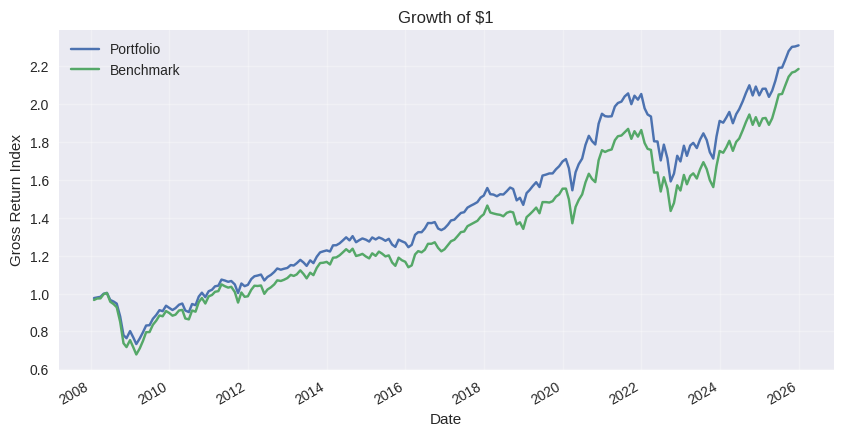

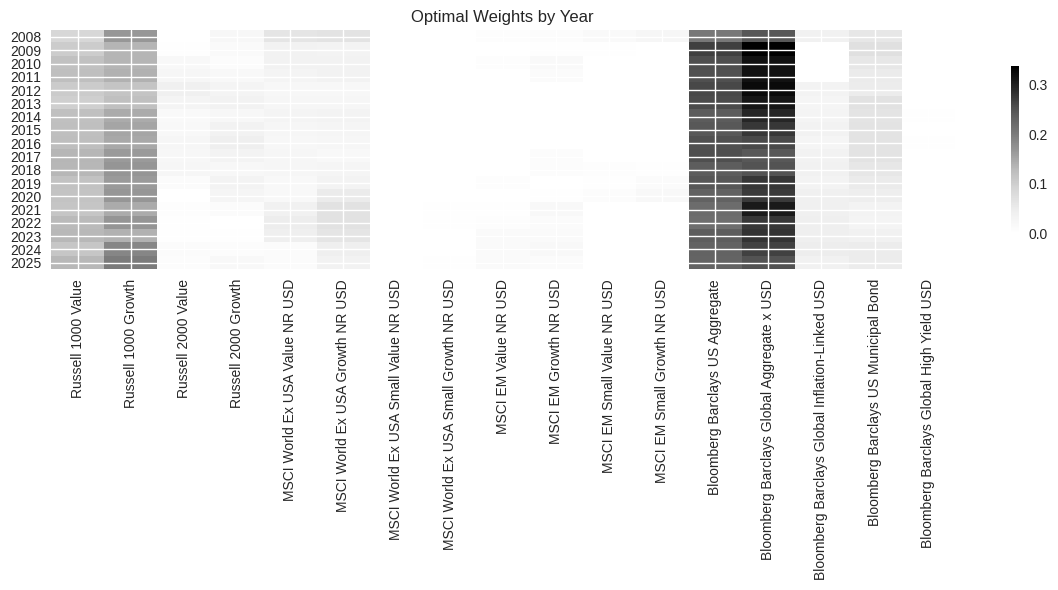

In [11]:
# 7) 可视化：Growth of $1 + 年度权重热力图

growth = pd.DataFrame({
    "Portfolio": (1 + port_rets).cumprod(),
    "Benchmark": (1 + bmk_rets).cumprod(),
})

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
growth.plot(ax=ax)
ax.set_title("Growth of $1")
ax.set_ylabel("Gross Return Index")
ax.grid(True, alpha=0.3)
plt.show()

w_opt_df = pd.DataFrame(weights_opt, index=assets).T

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(w_opt_df.values, aspect="auto")
ax.set_title("Optimal Weights by Year")
ax.set_xticks(range(len(assets)))
ax.set_xticklabels(assets, rotation=90)
ax.set_yticks(range(len(w_opt_df.index)))
ax.set_yticklabels(w_opt_df.index)
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

In [12]:
# 8) 导出老师要求里常见的年度表（Weights / Parameters / Expected Returns）

weights_mkt_df = pd.DataFrame(weights_mkt, index=assets).T
weights_opt_df = pd.DataFrame(weights_opt, index=assets).T
pi_df = pd.DataFrame(mu_pi_dict, index=assets).T
bl_df = pd.DataFrame(mu_bl_dict, index=assets).T

params_df = pd.DataFrame({
    "delta": [delta] * len(weights_opt_df),
    "tau": [tau] * len(weights_opt_df),
    "omega_scale": [omega_scale] * len(weights_opt_df),
}, index=weights_opt_df.index)

print("Market weights (head):")
display(weights_mkt_df.head())
print("Optimal weights (head):")
display(weights_opt_df.head())
print("Expected returns - pi (head):")
display(pi_df.head())
print("Expected returns - BL (head):")
display(bl_df.head())
print("Parameters:")
display(params_df.head())

Market weights (head):


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
2008,0.105894,0.116790,0.008966,0.010368,0.112815,0.114770,0.012333,0.013049,0.027059,0.025616,0.003689,0.003643,0.152601,0.242529,0.018546,0.016292,0.015041
2009,0.085050,0.084437,0.007504,0.006762,0.077836,0.082677,0.006758,0.007671,0.016618,0.015179,0.002117,0.002086,0.218227,0.331605,0.023331,0.020465,0.011676
2010,0.082034,0.084239,0.007250,0.006860,0.084126,0.085389,0.010242,0.010247,0.023744,0.024559,0.003185,0.003280,0.204433,0.313518,0.021263,0.018378,0.017254
2011,0.086912,0.088478,0.007760,0.008136,0.080998,0.084398,0.011322,0.012001,0.025593,0.025708,0.003579,0.003541,0.203627,0.302291,0.020546,0.016322,0.018788
2012,0.087576,0.087230,0.007466,0.007499,0.071997,0.072229,0.009962,0.010004,0.021123,0.021972,0.002779,0.002786,0.215712,0.320389,0.024547,0.017390,0.019339


Optimal weights (head):


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
2008,0.087814,0.166790,0.000924,0.021207,0.062815,0.064770,0.000000e+00,0.000000e+00,5.883964e-03,0.007590,1.456999e-02,2.446066e-02,0.202601,0.245366,3.863093e-02,0.056578,2.710505e-18
2009,0.103020,0.134437,0.002282,0.012507,0.036007,0.032677,0.000000e+00,0.000000e+00,0.000000e+00,0.002591,1.323699e-03,2.985394e-05,0.268227,0.336434,9.860593e-18,0.070465,1.549234e-17
2010,0.120363,0.134239,0.017645,0.007590,0.034960,0.035389,0.000000e+00,1.710184e-19,5.957307e-03,0.014902,0.000000e+00,9.824387e-19,0.254433,0.316486,0.000000e+00,0.058035,9.490148e-19
2011,0.122300,0.138478,0.025948,0.017763,0.030998,0.034398,0.000000e+00,7.312315e-19,6.863497e-04,0.010653,0.000000e+00,0.000000e+00,0.253596,0.314267,8.836957e-18,0.050912,0.000000e+00
2012,0.104580,0.114703,0.039805,0.030428,0.021997,0.022229,1.263856e-18,1.352254e-19,2.476895e-19,0.000000,9.261051e-19,1.872919e-18,0.260302,0.323710,3.285071e-02,0.049397,0.000000e+00


Expected returns - pi (head):


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
2008,0.008763,0.008431,0.010945,0.014287,0.012906,0.013057,0.012840,0.015313,0.022201,0.022226,0.020280,0.020404,0.000251,0.003730,0.002586,0.000596,0.005003
2009,0.029764,0.032970,0.032507,0.040013,0.042676,0.044255,0.047579,0.052345,0.059450,0.062547,0.064801,0.068445,0.005019,0.012900,0.020079,0.005298,0.030728
2010,0.060451,0.056743,0.064754,0.066218,0.077740,0.071408,0.081860,0.080324,0.095292,0.094875,0.105509,0.107439,0.007591,0.023054,0.029876,0.006745,0.046439
2011,0.075556,0.071514,0.083063,0.082953,0.096692,0.087797,0.101327,0.098941,0.108878,0.108916,0.121084,0.121619,0.006738,0.029404,0.035147,0.006012,0.054080
2012,0.054520,0.045802,0.061877,0.056229,0.066409,0.058188,0.065239,0.059204,0.067738,0.066283,0.072995,0.069704,0.001659,0.023386,0.019470,-0.000250,0.027052


Expected returns - BL (head):


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
2008,0.006329,0.007417,0.007935,0.011248,0.008950,0.009192,0.008752,0.010573,0.016542,0.016941,0.015440,0.015724,0.000654,0.003086,0.002376,0.000676,0.003454
2009,0.022596,0.025409,0.024605,0.030023,0.031384,0.031961,0.034924,0.037808,0.043119,0.045242,0.047800,0.050259,0.004332,0.009860,0.015120,0.004653,0.022772
2010,0.051216,0.047103,0.055107,0.054579,0.062780,0.056406,0.064803,0.062446,0.075298,0.074510,0.082722,0.083854,0.006608,0.019093,0.023990,0.005459,0.035454
2011,0.064029,0.059642,0.071283,0.069262,0.078161,0.069770,0.080517,0.077736,0.086156,0.085814,0.094920,0.094953,0.005735,0.024088,0.027751,0.004703,0.041031
2012,0.046267,0.038780,0.052992,0.047291,0.052967,0.045837,0.050658,0.045792,0.053016,0.051866,0.055483,0.052870,0.001668,0.019097,0.015690,-0.000532,0.019426


Parameters:


,delta,tau,omega_scale
2008,2.5,0.05,4.0
2009,2.5,0.05,4.0
2010,2.5,0.05,4.0
2011,2.5,0.05,4.0
2012,2.5,0.05,4.0


In [13]:
# 9) 最后一年 Covariances / Volatilities / Correlations

final_year = max(cov_dict.keys())
final_cov = pd.DataFrame(cov_dict[final_year], index=assets, columns=assets)
final_vol = pd.Series(np.sqrt(np.diag(final_cov)), index=assets, name="Ann Vol")
final_cor = final_cov.div(final_vol, axis=0).div(final_vol, axis=1)

print("Final year:", final_year)
print("Covariances:")
display(final_cov)
print("Volatilities:")
display(final_vol.to_frame())
print("Correlations:")
display(final_cor)

Final year: 2025
Covariances:


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
Russell 1000 Value,0.028533,0.026336,0.036701,0.035440,0.023465,0.027119,0.025540,0.029016,0.016858,0.018704,0.016872,0.018587,0.009064,0.013260,0.015630,0.008711,0.013582
Russell 1000 Growth,0.026336,0.042514,0.032966,0.039916,0.019267,0.033002,0.022841,0.032619,0.019012,0.023697,0.019784,0.025457,0.011050,0.014461,0.018346,0.010972,0.015549
Russell 2000 Value,0.036701,0.032966,0.056492,0.053909,0.028796,0.032619,0.033519,0.038040,0.019843,0.021087,0.020770,0.022852,0.011438,0.015983,0.019287,0.010769,0.016875
Russell 2000 Growth,0.035440,0.039916,0.053909,0.059209,0.024808,0.035800,0.030638,0.039468,0.019540,0.022145,0.020287,0.024757,0.012379,0.016183,0.019866,0.011961,0.016991
MSCI World Ex USA Value NR USD,0.023465,0.019267,0.028796,0.024808,0.026062,0.025534,0.027199,0.028073,0.020590,0.022187,0.018556,0.019822,0.009065,0.014289,0.015074,0.008398,0.013443
MSCI World Ex USA Growth NR USD,0.027119,0.033002,0.032619,0.035800,0.025534,0.035978,0.029146,0.036437,0.022989,0.026962,0.021594,0.025587,0.012441,0.017765,0.019863,0.012190,0.016423
MSCI World Ex USA Small Value NR USD,0.025540,0.022841,0.033519,0.030638,0.027199,0.029146,0.030598,0.033009,0.021973,0.024430,0.020797,0.022545,0.010701,0.016155,0.017533,0.009810,0.015175
MSCI World Ex USA Small Growth NR USD,0.029016,0.032619,0.038040,0.039468,0.028073,0.036437,0.033009,0.039893,0.024353,0.028441,0.023815,0.027686,0.013126,0.018762,0.020824,0.012451,0.017861
MSCI EM Value NR USD,0.016858,0.019012,0.019843,0.019540,0.020590,0.022989,0.021973,0.024353,0.026204,0.030430,0.020787,0.023617,0.008966,0.013769,0.013787,0.009177,0.011962
MSCI EM Growth NR USD,0.018704,0.023697,0.021087,0.022145,0.022187,0.026962,0.024430,0.028441,0.030430,0.038216,0.023855,0.028301,0.010818,0.015992,0.016129,0.011615,0.014221


Volatilities:


,Ann Vol
Russell 1000 Value,0.168916
Russell 1000 Growth,0.206188
Russell 2000 Value,0.237681
Russell 2000 Growth,0.243329
MSCI World Ex USA Value NR USD,0.161438
MSCI World Ex USA Growth NR USD,0.189677
MSCI World Ex USA Small Value NR USD,0.174922
MSCI World Ex USA Small Growth NR USD,0.199732
MSCI EM Value NR USD,0.161875
MSCI EM Growth NR USD,0.195490


Correlations:


,Russell 1000 Value,Russell 1000 Growth,Russell 2000 Value,Russell 2000 Growth,MSCI World Ex USA Value NR USD,MSCI World Ex USA Growth NR USD,MSCI World Ex USA Small Value NR USD,MSCI World Ex USA Small Growth NR USD,MSCI EM Value NR USD,MSCI EM Growth NR USD,MSCI EM Small Value NR USD,MSCI EM Small Growth NR USD,Bloomberg Barclays US Aggregate,Bloomberg Barclays Global Aggregate x USD,Bloomberg Barclays Global Inflation-Linked USD,Bloomberg Barclays US Municipal Bond,Bloomberg Barclays Global High Yield USD
Russell 1000 Value,1.000000,0.756169,0.914136,0.862247,0.860487,0.846407,0.864386,0.860055,0.616542,0.566424,0.692559,0.663265,0.685161,0.717776,0.793257,0.673389,0.843499
Russell 1000 Growth,0.756169,1.000000,0.672675,0.795593,0.578816,0.843851,0.633309,0.792069,0.569621,0.587913,0.665288,0.744207,0.684284,0.641287,0.762794,0.694873,0.791097
Russell 2000 Value,0.914136,0.672675,1.000000,0.932125,0.750476,0.723545,0.806208,0.801302,0.515732,0.453832,0.605917,0.579544,0.614467,0.614889,0.695645,0.591618,0.744785
Russell 2000 Growth,0.862247,0.795593,0.932125,1.000000,0.631518,0.775653,0.719806,0.812089,0.496069,0.465546,0.578089,0.613280,0.649573,0.608146,0.699917,0.641865,0.732495
MSCI World Ex USA Value NR USD,0.860487,0.578816,0.750476,0.631518,1.000000,0.833869,0.963155,0.870631,0.787913,0.703030,0.796992,0.740101,0.716946,0.809325,0.800464,0.679260,0.873549
MSCI World Ex USA Growth NR USD,0.846407,0.843851,0.723545,0.775653,0.833869,1.000000,0.878455,0.961785,0.748714,0.727130,0.789363,0.813111,0.837461,0.856401,0.897758,0.839197,0.908306
MSCI World Ex USA Small Value NR USD,0.864386,0.633309,0.806208,0.719806,0.963155,0.878455,1.000000,0.944799,0.776023,0.714418,0.824377,0.776897,0.781133,0.844468,0.859288,0.732285,0.910072
MSCI World Ex USA Small Growth NR USD,0.860055,0.792069,0.801302,0.812089,0.870631,0.961785,0.944799,1.000000,0.753213,0.728401,0.826742,0.835536,0.839092,0.858949,0.893798,0.814002,0.938112
MSCI EM Value NR USD,0.616542,0.569621,0.515732,0.496069,0.787913,0.748714,0.776023,0.753213,1.000000,0.961606,0.890388,0.879435,0.707246,0.777756,0.730137,0.740257,0.775174
MSCI EM Growth NR USD,0.566424,0.587913,0.453832,0.465546,0.703030,0.727130,0.714418,0.728401,0.961606,1.000000,0.846085,0.872613,0.706588,0.748016,0.707319,0.775849,0.763148


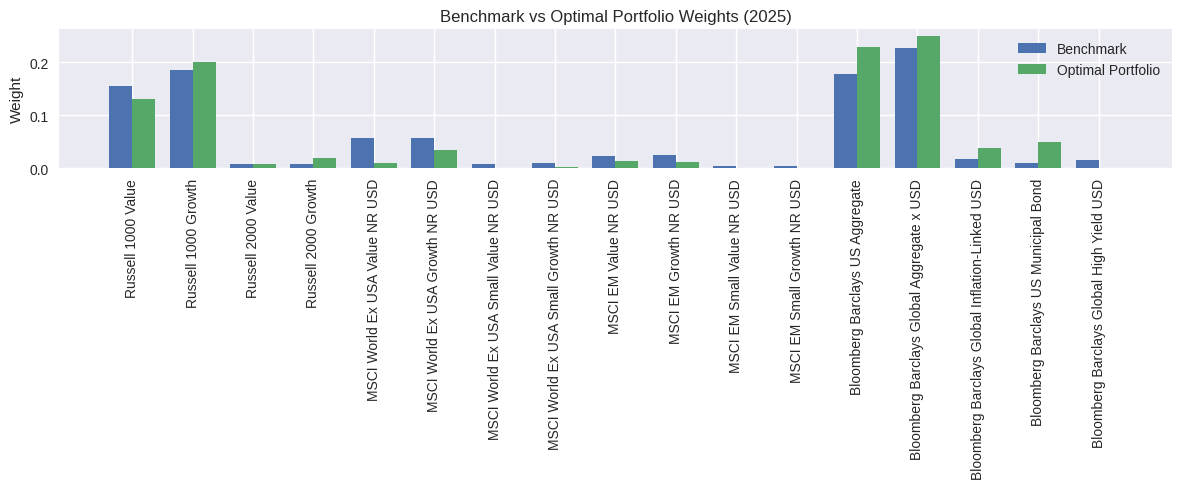

In [15]:
years = sorted(weights_mkt.keys())
final_year = years[-1]

w_mkt_final = pd.Series(weights_mkt[final_year], index=assets)
w_opt_final = pd.Series(weights_opt[final_year], index=assets)

x = np.arange(len(assets))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, w_mkt_final.values, width=width, label="Benchmark")
plt.bar(x + width/2, w_opt_final.values, width=width, label="Optimal Portfolio")
plt.xticks(x, assets, rotation=90)
plt.ylabel("Weight")
plt.title(f"Benchmark vs Optimal Portfolio Weights ({final_year})")
plt.legend()
plt.tight_layout()
plt.show()

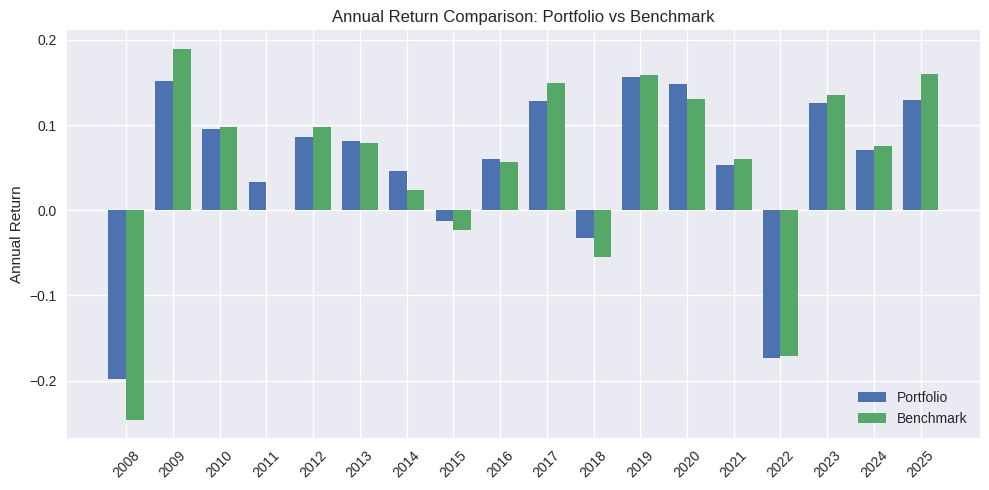

In [16]:
annual_port = (1 + port_rets).groupby(port_rets.index.year).prod() - 1
annual_bmk = (1 + bmk_rets).groupby(bmk_rets.index.year).prod() - 1

years = annual_port.index.astype(str)
x = np.arange(len(years))
width = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, annual_port.values, width=width, label="Portfolio")
plt.bar(x + width/2, annual_bmk.values, width=width, label="Benchmark")
plt.xticks(x, years, rotation=45)
plt.ylabel("Annual Return")
plt.title("Annual Return Comparison: Portfolio vs Benchmark")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
wealth_port = (1 + port_rets).cumprod()
wealth_bmk = (1 + bmk_rets).cumprod()

ann_ret_port = wealth_port.iloc[-1] ** (12 / len(port_rets)) - 1
ann_ret_bmk = wealth_bmk.iloc[-1] ** (12 / len(bmk_rets)) - 1

ann_vol_port = port_rets.std(ddof=1) * np.sqrt(12)
ann_vol_bmk = bmk_rets.std(ddof=1) * np.sqrt(12)

active_rets = port_rets - bmk_rets
ann_active_return = active_rets.mean() * 12
tracking_error = active_rets.std(ddof=1) * np.sqrt(12)
information_ratio = ann_active_return / tracking_error

summary_df = pd.DataFrame({
    "Portfolio": [ann_ret_port, ann_vol_port],
    "Benchmark": [ann_ret_bmk, ann_vol_bmk]
}, index=["Geometric Annual Return", "Annualized Volatility"])

active_df = pd.DataFrame({
    "Value": [ann_active_return, tracking_error, information_ratio]
}, index=["Annualized Active Return", "Tracking Error", "Information Ratio"])

print("Total Return Statistics")
display(summary_df)

print("Active Return Statistics")
display(active_df)

Total Return Statistics


,Portfolio,Benchmark
Geometric Annual Return,0.047627,0.044409
Annualized Volatility,0.087823,0.100079


Active Return Statistics


,Value
Annualized Active Return,0.001917
Tracking Error,0.017063
Information Ratio,0.112336


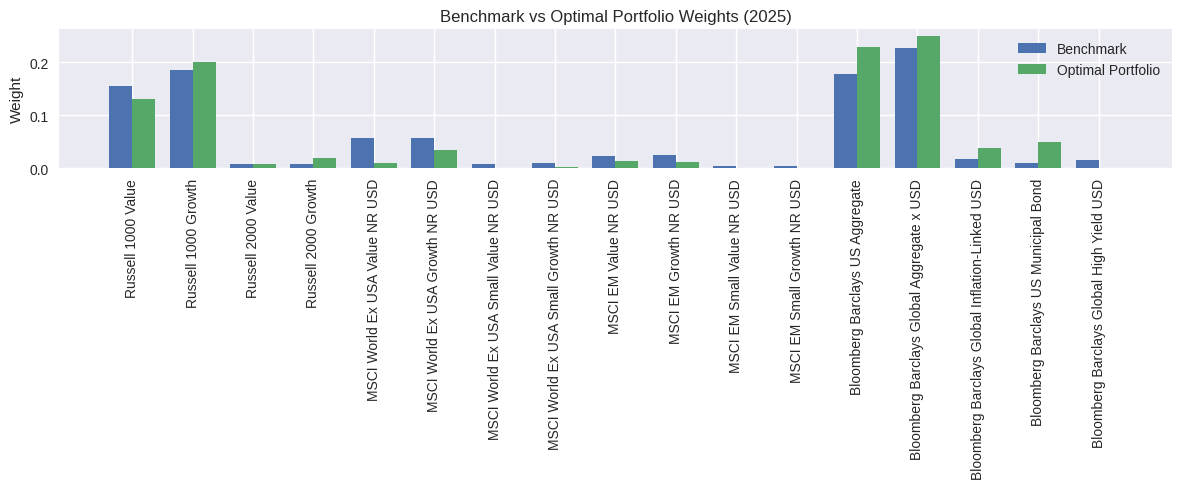

In [20]:
years = sorted(weights_mkt.keys())
final_year = years[-1]

w_mkt_final = pd.Series(weights_mkt[final_year], index=assets)
w_opt_final = pd.Series(weights_opt[final_year], index=assets)

x = np.arange(len(assets))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, w_mkt_final.values, width=width, label="Benchmark")
plt.bar(x + width/2, w_opt_final.values, width=width, label="Optimal Portfolio")
plt.xticks(x, assets, rotation=90)
plt.ylabel("Weight")
plt.title(f"Benchmark vs Optimal Portfolio Weights ({final_year})")
plt.legend()
plt.tight_layout()
plt.show()

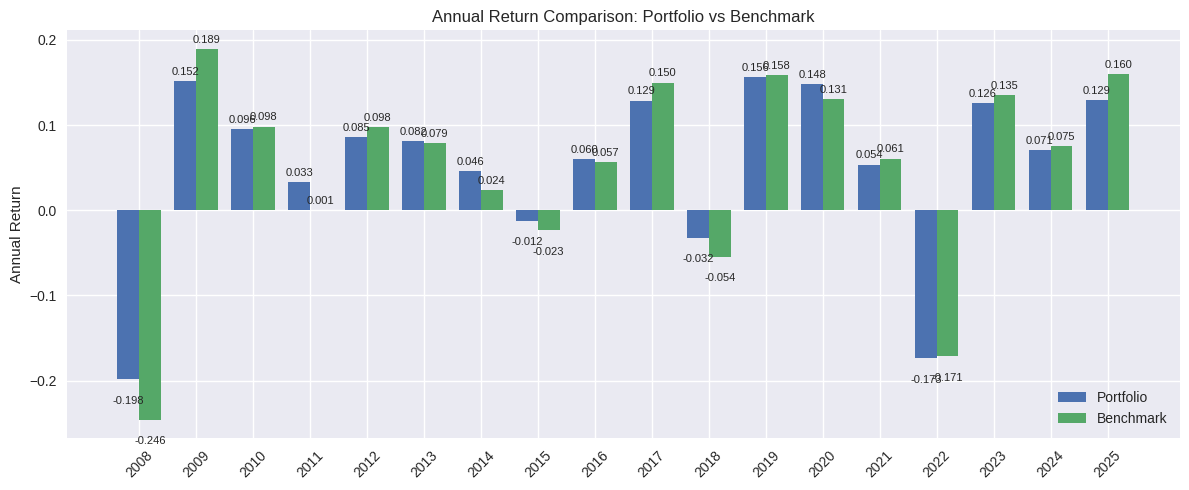

In [25]:
annual_port = (1 + port_rets).groupby(port_rets.index.year).prod() - 1
annual_bmk = (1 + bmk_rets).groupby(bmk_rets.index.year).prod() - 1

years = annual_port.index.astype(str)
x = np.arange(len(years))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, annual_port.values, width=width, label="Portfolio")
bars2 = ax.bar(x + width/2, annual_bmk.values, width=width, label="Benchmark")

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_ylabel("Annual Return")
ax.set_title("Annual Return Comparison: Portfolio vs Benchmark")
ax.legend()

# add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3 if h >= 0 else -12),
                    textcoords="offset points",
                    ha="center",
                    va="bottom" if h >= 0 else "top",
                    fontsize=8)

plt.tight_layout()
plt.show()

In [23]:
wealth_port = (1 + port_rets).cumprod()
wealth_bmk = (1 + bmk_rets).cumprod()

ann_ret_port = wealth_port.iloc[-1] ** (12 / len(port_rets)) - 1
ann_ret_bmk = wealth_bmk.iloc[-1] ** (12 / len(bmk_rets)) - 1

ann_vol_port = port_rets.std(ddof=1) * np.sqrt(12)
ann_vol_bmk = bmk_rets.std(ddof=1) * np.sqrt(12)

active_rets = port_rets - bmk_rets
ann_active_return = active_rets.mean() * 12
tracking_error = active_rets.std(ddof=1) * np.sqrt(12)
information_ratio = ann_active_return / tracking_error

summary_df = pd.DataFrame({
    "Portfolio": [ann_ret_port, ann_vol_port],
    "Benchmark": [ann_ret_bmk, ann_vol_bmk]
}, index=["Geometric Annual Return", "Annualized Volatility"])

active_df = pd.DataFrame({
    "Value": [ann_active_return, tracking_error, information_ratio]
}, index=["Annualized Active Return", "Tracking Error", "Information Ratio"])

print("Total Return Statistics")
display(summary_df)

print("Active Return Statistics")
display(active_df)

Total Return Statistics


,Portfolio,Benchmark
Geometric Annual Return,0.047627,0.044409
Annualized Volatility,0.087823,0.100079


Active Return Statistics


,Value
Annualized Active Return,0.001917
Tracking Error,0.017063
Information Ratio,0.112336


In [24]:
annual_compare = pd.DataFrame({
    "Portfolio": annual_port,
    "Benchmark": annual_bmk
})
display(annual_compare)


,Portfolio,Benchmark
Date,,
2008,-0.197998,-0.245685
2009,0.152029,0.189363
2010,0.095710,0.098138
2011,0.033285,0.000614
2012,0.085423,0.097616
2013,0.081570,0.078940
2014,0.045926,0.024118
2015,-0.012399,-0.023125
2016,0.059963,0.056514
